In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import io
import logging
import re
import os
import json
from datetime import datetime, timedelta

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')


### 1. Carregar o Dataset

In [3]:
url = "https://www.bcb.gov.br/pda/desig/desenrola/dados_desenrola.csv"
local_file = "../data/raw/dados_desenrola.csv"
csv_config_br = {"sep": ";", "decimal": ",", "encoding": "utf-8"}

def extract_data(url: str, local_file: str, csv_config: dict) -> pd.DataFrame:
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
    try:
        logging.info("Tentando baixar o dataset online...")
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()
        logging.info("Download bem-sucedido. Carregando os dados...")
        df = pd.read_csv(
            io.StringIO(response.text),
            **csv_config
            )
        logging.info(f"Dados extraídos com sucesso da internet. [{len(df)}] registros encontrados.")
    except Exception as e:
        logging.error(f"Não foi possível baixar da internet. Motivo: {e}")
        logging.info("Utilizando arquivo local como alternativa...")
        df = pd.read_csv(
            local_file,
            **csv_config
            )
        logging.info(f"Dados extraídos com sucesso de arquivo local. [{len(df)}] registros encontrados.")
    return df

df_raw = extract_data(url, local_file, csv_config_br)
df_raw.info()


INFO - Tentando baixar o dataset online...
INFO - Download bem-sucedido. Carregando os dados...
INFO - Dados extraídos com sucesso da internet. [10598] registros encontrados.


<class 'pandas.DataFrame'>
RangeIndex: 10598 entries, 0 to 10597
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   DATA_BASE                     10598 non-null  int64  
 1   TIPO_DESENROLA                10598 non-null  int64  
 2   UNIDADE_FEDERACAO             10598 non-null  str    
 3   COD_CONGLOMERADO_FINANCEIRO   10598 non-null  int64  
 4   NOME_CONGLOMERADO_FINANCEIRO  10598 non-null  str    
 5   NUMERO_OPERACOES              10598 non-null  int64  
 6   VOLUME_OPERACOES              10598 non-null  float64
dtypes: float64(1), int64(4), str(2)
memory usage: 579.7 KB


#### 1.5 Sujar o Dataset para limpeza posterior

In [4]:
def dirty_data(df, noise_level=0.02):
    # Cria uma cópia "suja" de parte do dataframe original (preservando os dados limpos) e adiciona essa cópia ao final do dataframe original.
    df_clean = df.copy()
    corrupted_rows = []
    
    # Introduz valores nulos
    df_nulls = df_clean.sample(frac=noise_level).copy()
    for col in df_nulls.columns:
        df_nulls.loc[df_nulls.sample(frac=0.5).index, col] = np.nan
    corrupted_rows.append(df_nulls)
    
    # Introduz espaços em branco em colunas de texto
    df_text_columns = df_clean.select_dtypes(include=['object', 'string']).columns
    if not df_text_columns.empty:
        df_spaces = df_clean.sample(frac=noise_level).copy()
        for col in df_text_columns:
            df_spaces[col] = '   ' + df_spaces[col].astype(str) + '   '
        corrupted_rows.append(df_spaces)
        
    # Introduz datas inválidas
    df_dates = df_clean.sample(frac=noise_level).copy()
    df_dates['DATA_BASE'] = 'invalid_date'
    corrupted_rows.append(df_dates)
        
    # Introduz outliers em colunas numéricas
    numeric_columns = df_clean.select_dtypes(include=np.number).columns
    if not numeric_columns.empty:
        df_outliers = df_clean.sample(frac=noise_level).copy()
        for column in numeric_columns:
            df_outliers[column] = df_clean[column].max() * 10
        corrupted_rows.append(df_outliers)
        
    # Introduz duplicatas
    df_duplicates = df_clean.sample(frac=noise_level).copy()
    corrupted_rows.append(df_duplicates)
    
    df_dirty = pd.concat([df_clean] + corrupted_rows, ignore_index=True)

    # Converte as colunas de inteiros para Int64 para permitir valores nulos, mantendo a consistência de tipo com o dataframe original.
    int_cols = df_clean.select_dtypes(include='int64').columns
    int_cols = [col for col in int_cols if col != 'DATA_BASE'] # Filtra e remove a coluna de data
    for col in int_cols:
        df_dirty[col] = df_dirty[col].astype('Int64')

    return df_dirty

df_dirty = dirty_data(df_raw)
os.makedirs("../data/raw", exist_ok=True)
df_dirty.to_csv("../data/raw/desenrola_sujo.csv", index=False)
print(f"Dataset gerado com {len(df_dirty)} registros.")
print(df_dirty.tail())


Dataset gerado com 11658 registros.
      DATA_BASE  TIPO_DESENROLA UNIDADE_FEDERACAO  \
11653    202310               1                PI   
11654    202501               1                PE   
11655    202405               1                PR   
11656    202601               1                GO   
11657    202408               3                RS   

       COD_CONGLOMERADO_FINANCEIRO NOME_CONGLOMERADO_FINANCEIRO  \
11653                        30379                    SANTANDER   
11654                        80075        BRADESCO - PRUDENCIAL   
11655                        10045                     BRADESCO   
11656                        84693   NU PAGAMENTOS - PRUDENCIAL   
11657                        10069                         ITAU   

       NUMERO_OPERACOES  VOLUME_OPERACOES  
11653               125         101150.92  
11654                 6             63.94  
11655               315         384560.60  
11656                 3            399.81  
11657               11

### 2. Inspecionar o Dataset

In [5]:
def inspect_data(df):
    print ("\n=== INSPEÇÃO INICIAL DO DATASET ===")
    print (f"Shape: {df.shape}")
    print (f"\nColunas: {list(df.columns)}")
    print (f"\nTipos de dados:\n{df.dtypes}")
    print (f"\nValores nulos por coluna:\n{df.isnull().sum()}")
    print (f"\nPrimeiros registros:\n{df.head()}")
    print (f"\nEstatísticas descritivas:\n{df.describe()}")
    return df.describe(include= "all" )

inspect_data(df_dirty)


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (11658, 7)

Colunas: ['DATA_BASE', 'TIPO_DESENROLA', 'UNIDADE_FEDERACAO', 'COD_CONGLOMERADO_FINANCEIRO', 'NOME_CONGLOMERADO_FINANCEIRO', 'NUMERO_OPERACOES', 'VOLUME_OPERACOES']

Tipos de dados:
DATA_BASE                        object
TIPO_DESENROLA                    Int64
UNIDADE_FEDERACAO                   str
COD_CONGLOMERADO_FINANCEIRO       Int64
NOME_CONGLOMERADO_FINANCEIRO        str
NUMERO_OPERACOES                  Int64
VOLUME_OPERACOES                float64
dtype: object

Valores nulos por coluna:
DATA_BASE                       106
TIPO_DESENROLA                  106
UNIDADE_FEDERACAO               106
COD_CONGLOMERADO_FINANCEIRO     106
NOME_CONGLOMERADO_FINANCEIRO    106
NUMERO_OPERACOES                106
VOLUME_OPERACOES                106
dtype: int64

Primeiros registros:
  DATA_BASE  TIPO_DESENROLA UNIDADE_FEDERACAO  COD_CONGLOMERADO_FINANCEIRO  \
0    202309               2                AC                        49906  

,DATA_BASE,TIPO_DESENROLA,UNIDADE_FEDERACAO,COD_CONGLOMERADO_FINANCEIRO,NOME_CONGLOMERADO_FINANCEIRO,NUMERO_OPERACOES,VOLUME_OPERACOES
count,11552.0,11552.0,11552,11552.0,11552,11552.0,1.155200e+04
unique,34.0,<NA>,54,<NA>,109,<NA>,NaN
top,202311.0,<NA>,SP,<NA>,BRADESCO,<NA>,NaN
freq,726.0,<NA>,627,<NA>,986,<NA>,NaN
mean,NaN,2.053843,NaN,16922608.00026,NaN,8769.044668,4.024171e+07
std,NaN,3.885876,NaN,116625772.626408,NaN,62245.947191,2.888997e+08
min,NaN,1.0,NaN,10045.0,NaN,1.0,1.000000e-02
25%,NaN,1.0,NaN,30379.0,NaN,2.0,1.194640e+03
50%,NaN,1.0,NaN,51750.0,NaN,9.0,1.868051e+04
75%,NaN,2.0,NaN,80185.0,NaN,89.0,2.945965e+05


### 3. Limpar e Tratar os Dados

In [ ]:
def normalize_string(text):
    # Função auxiliar para normalizar espaços em branco em uma célula, preservando valores nulos
    if pd.isna(text):
        return text
    cleaned_text = str(text)
    cleaned_text = re.sub(r"\s+", " ", cleaned_text)
    return cleaned_text.strip()

def clean_strings(df, columns):
    df = df.copy()
    for column in columns:
        df[column] = df[column].apply(lambda cell: normalize_string(cell))
    return df

def clean_dates(df, columns):
    df = df.copy()
    for column in columns:
        df[column] = pd.to_datetime(df[column], format='%Y%m', errors='coerce')
    return df

def fill_missing_institution_names(df):
    # Função auxiliar para preencher os valores nulos na coluna de nome do conglomerado financeiro tomando como base o código do conglomerado financeiro, já que cada código corresponde a uma instituição financeira específica. (imputação baseada em mapeamento).
    mapping = (
        df.dropna(subset=["NOME_CONGLOMERADO_FINANCEIRO"])
        .drop_duplicates(subset=["COD_CONGLOMERADO_FINANCEIRO"])
        .set_index("COD_CONGLOMERADO_FINANCEIRO")["NOME_CONGLOMERADO_FINANCEIRO"]
        .to_dict()
        )
    replacement_values = df["COD_CONGLOMERADO_FINANCEIRO"].map(mapping)
    df["NOME_CONGLOMERADO_FINANCEIRO"] = df["NOME_CONGLOMERADO_FINANCEIRO"].fillna(replacement_values)
    return df

def clean_data(df):
    # Função principal de limpeza de dados, que chama as funções auxiliares.
    df = df.copy()
    report = {}
    report["registros_iniciais"] = len(df)

    # Etapa 1: Limpa strings em colunas de texto.
    df = clean_strings(df, ["UNIDADE_FEDERACAO", "NOME_CONGLOMERADO_FINANCEIRO"])

    # Etapa 2: Converte a coluna de data para o tipo datetime e remove linhas sem data válida.
    df = clean_dates(df, ["DATA_BASE"])
    before = len(df)
    df = df.dropna(subset=["DATA_BASE"])
    report["datas_invalidas_removidas"] = before - len(df)

    # Etapa 3: Remove tipos do programa inválidos.
    # Só existem 3 tipos no programa Desenrola Brasil (1, 2 e 3); valores fora disso são inválidos.
    before = len(df)
    df = df[df["TIPO_DESENROLA"].isin([1, 2, 3])]
    report["tipos_invalidos_removidos"] = before - len(df)

    # Etapa 4: Preenche os valores nulos na coluna de nome do conglomerado financeiro.
    before_names = df["NOME_CONGLOMERADO_FINANCEIRO"].isna().sum()
    df = fill_missing_institution_names(df)
    after_names = df["NOME_CONGLOMERADO_FINANCEIRO"].isna().sum()
    report["nomes_instituicao_preenchidos"] = before_names - after_names

    # Etapa 4: Remove a coluna código do conglomerado financeiro, pois é redundante com o nome da instituição financeira.
    df = df.drop(columns=["COD_CONGLOMERADO_FINANCEIRO"])
   
    # Etapa 5: Remove registros restantes que ainda tenham valores nulos
    before = len(df)
    df = df.dropna()
    report["nulos_removidos"] = before - len(df)

    # Etapa 6: Remove registros duplicados
    before = len(df)
    df = df.drop_duplicates()
    report["registros_duplicados_removidos"] = before - len(df)

    # Etapa 7: Define tipos de dados corretos para colunas categóricas
    df["UNIDADE_FEDERACAO"] = df["UNIDADE_FEDERACAO"].astype("category")
    df["TIPO_DESENROLA"] = df["TIPO_DESENROLA"].astype("category")

    # Resumo final
    report["registros_finais"] = len(df)
    report["registros_removidos_total"] = report["registros_iniciais"] - len(df)

    print ("\n=== RELATÓRIO DE LIMPEZA DE DADOS ===")
    for etapa, valor in report.items():
        print(f"  {etapa}: {valor}")

    return df, report

df_v1, report = clean_data(df_dirty)

os.makedirs("../data/processed", exist_ok=True)
df_v1.to_csv("../data/processed/desenrola_v1.csv", index=False)
print("\nv1 salva em ../data/processed/")


=== RELATÓRIO DE LIMPEZA DE DADOS ===
  registros_iniciais: 11658
  datas_invalidas_removidas: 530
  tipos_invalidos_removidos: 50
  nomes_instituicao_preenchidos: 15
  nulos_removidos: 51
  registros_duplicados_removidos: 429
  registros_finais: 10598
  registros_removidos_total: 1060

v1 salva em ../data/processed/


### 4. Tratar Outliers


=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (10598, 6)

Colunas: ['DATA_BASE', 'TIPO_DESENROLA', 'UNIDADE_FEDERACAO', 'NOME_CONGLOMERADO_FINANCEIRO', 'NUMERO_OPERACOES', 'VOLUME_OPERACOES']

Tipos de dados:
DATA_BASE                       datetime64[us]
TIPO_DESENROLA                        category
UNIDADE_FEDERACAO                     category
NOME_CONGLOMERADO_FINANCEIRO               str
NUMERO_OPERACOES                         Int64
VOLUME_OPERACOES                       float64
dtype: object

Valores nulos por coluna:
DATA_BASE                       0
TIPO_DESENROLA                  0
UNIDADE_FEDERACAO               0
NOME_CONGLOMERADO_FINANCEIRO    0
NUMERO_OPERACOES                0
VOLUME_OPERACOES                0
dtype: int64

Primeiros registros:
   DATA_BASE TIPO_DESENROLA UNIDADE_FEDERACAO NOME_CONGLOMERADO_FINANCEIRO  \
0 2023-09-01              2                AC                           BB   
1 2023-09-01              2                AC                     BRADESCO 

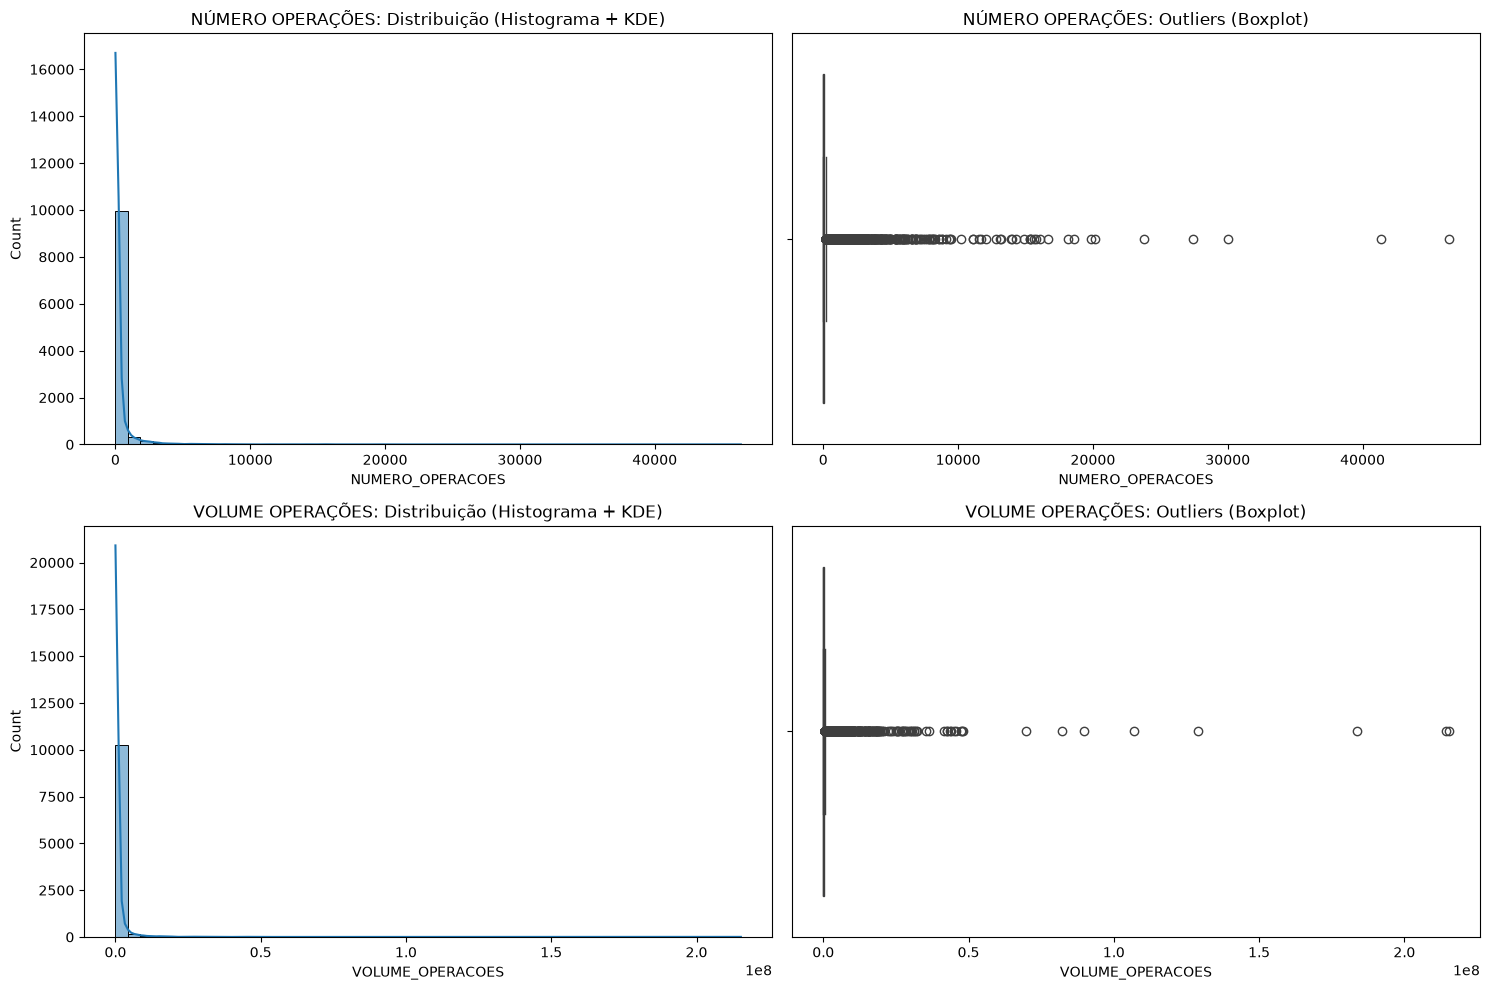

In [20]:
# Vamos olhar mais uma vez o dataset limpo para entender melhor os dados antes de tratar os outliers.
inspect_data(df_v1)

# Visualização da distribuição das colunas numéricas:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=df_v1, x="NUMERO_OPERACOES", kde=True, bins=50, ax=axes[0, 0])
axes[0, 0].set_title("NÚMERO OPERAÇÕES: Distribuição (Histograma + KDE)")

sns.boxplot(data=df_v1, x="NUMERO_OPERACOES", ax=axes[0, 1])
axes[0, 1].set_title("NÚMERO OPERAÇÕES: Outliers (Boxplot)")

sns.histplot(data=df_v1, x="VOLUME_OPERACOES", kde=True, bins=50, ax=axes[1, 0])
axes[1, 0].set_title("VOLUME OPERAÇÕES: Distribuição (Histograma + KDE)")

sns.boxplot(data=df_v1, x="VOLUME_OPERACOES", ax=axes[1, 1])
axes[1, 1].set_title("VOLUME OPERAÇÕES: Outliers (Boxplot)")

plt.tight_layout()
plt.show()


In [8]:
def calculate_iqr_bounds(series, factor=1.5):
    # Função auxiliar para calcular os limites inferior e superior usando o método IQR.
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return lower_bound, upper_bound

def treat_outliers_iqr(df, columns, factor=1.5, method="remove", logarithmic=False):
    # Trata outliers numéricos via IQR. method='remove' ou 'limit'. O parâmetro `logarithmic` indica se deve aplicar uma transformação logarítmica aos dados antes de calcular os limites do IQR.
    df = df.copy()
    bounds = {}

    for column in columns:
        if logarithmic:
            log_series = np.log1p(df[column])
            log_lower, log_upper = calculate_iqr_bounds(log_series, factor)
            # Volta os limites para a escala original usando a função inversa da transformação logarítmica (exponencial):
            lower_bound = np.expm1(log_lower)
            upper_bound = np.expm1(log_upper)
        else:
            lower_bound, upper_bound = calculate_iqr_bounds(df[column], factor)
            
        bounds[column] = (lower_bound, upper_bound)
        is_outlier = (df[column] < lower_bound) | (df[column] > upper_bound)
        
        logging.info(
            f"Coluna '{column}': Encontrados {is_outlier.sum()} outliers "
            f"(limite_inferior={lower_bound:.2f}, limite_superior={upper_bound:.2f})"
        )

    for column in columns:
        lower_bound, upper_bound = bounds[column]
        if method == "remove":
            is_valid = (df[column] >= lower_bound) & (df[column] <= upper_bound)
            df = df[is_valid]
        elif method == "limit":
            df.loc[df[column] < lower_bound, column] = lower_bound
            df.loc[df[column] > upper_bound, column] = upper_bound
            
    return df


df_v2 = treat_outliers_iqr(df_v1, columns=["NUMERO_OPERACOES", "VOLUME_OPERACOES"], method="remove", logarithmic=True)
print(f"v1={len(df_v1)} | v2={len(df_v2)} | removidas={len(df_v1)-len(df_v2)}")
df_v2.to_csv("../data/processed/desenrola_v2.csv", index=False)
print("v2 salva.")

INFO - Coluna 'NUMERO_OPERACOES': Encontrados 29 outliers (limite_inferior=-0.98, limite_superior=9689.63)
INFO - Coluna 'VOLUME_OPERACOES': Encontrados 0 outliers (limite_inferior=-0.67, limite_superior=872928944.90)


v1=10598 | v2=10569 | removidas=29
v2 salva.


### 5. Criar Colunas Derivadas com Transformações

In [9]:
def create_derived_columns(df):
    # Cria colunas calculadas a partir do dataset limpo:
    df = df.copy()

    # Colunas de data:
    df["MES"] = df["DATA_BASE"].dt.month
    df["TRIMESTRE"] = df["DATA_BASE"].dt.quarter.apply(lambda q: f"Q{q}")
    df["ANO"] = df[ "DATA_BASE" ].dt.year

    # Valor médio da operação, calculado como volume / número de operações:
    df["MEDIA_OPERACAO"] = df["VOLUME_OPERACOES"] / df["NUMERO_OPERACOES"]
    
    # Faixas de volume das operações (dividindo terços através do pd.qcut)
    labels = ["Volume Baixo", "Volume Médio", "Volume Alto"]
    df["FAIXA_VOLUME"] = pd.qcut(df["VOLUME_OPERACOES"], q=3, labels=labels)

    # Número de operações em escala logarítmica:
    df["LOG_NUMERO_OPERACOES"] = np.log1p(df["NUMERO_OPERACOES"])

    # Volume de operações em escala logarítmica:
    df["LOG_VOLUME_OPERACOES"] = np.log1p(df["VOLUME_OPERACOES"])

    print("COLUNAS DERIVADAS CRIADAS")
    print(df[["MES", "TRIMESTRE", "ANO", "MEDIA_OPERACAO", "FAIXA_VOLUME", "LOG_NUMERO_OPERACOES", "LOG_VOLUME_OPERACOES", "FAIXA_VOLUME"]].head())
    return df

df = create_derived_columns(df_v2)
df[["MES", "TRIMESTRE", "ANO", "MEDIA_OPERACAO", "FAIXA_VOLUME", "LOG_NUMERO_OPERACOES", "LOG_VOLUME_OPERACOES"]].head()

COLUNAS DERIVADAS CRIADAS
   MES TRIMESTRE   ANO  MEDIA_OPERACAO  FAIXA_VOLUME  LOG_NUMERO_OPERACOES  \
0    9        Q3  2023    10131.399929   Volume Alto               4.94876   
1    9        Q3  2023     5588.652667  Volume Médio              2.772589   
2    9        Q3  2023     5398.398571  Volume Médio              2.079442   
3    9        Q3  2023     3038.838519   Volume Alto              4.406719   
4    9        Q3  2023        3076.715  Volume Médio              1.609438   

   LOG_VOLUME_OPERACOES  FAIXA_VOLUME  
0             14.165038   Volume Alto  
1             11.336556  Volume Médio  
2             10.539794  Volume Médio  
3             12.413684   Volume Alto  
4              9.417993  Volume Médio  


,MES,TRIMESTRE,ANO,MEDIA_OPERACAO,FAIXA_VOLUME,LOG_NUMERO_OPERACOES,LOG_VOLUME_OPERACOES
0,9,Q3,2023,10131.399929,Volume Alto,4.94876,14.165038
1,9,Q3,2023,5588.652667,Volume Médio,2.772589,11.336556
2,9,Q3,2023,5398.398571,Volume Médio,2.079442,10.539794
3,9,Q3,2023,3038.838519,Volume Alto,4.406719,12.413684
4,9,Q3,2023,3076.715,Volume Médio,1.609438,9.417993


### 6. Calcular Métricas Agregadas

In [18]:
# Volume de operações por mês
# Número de operações por mês
# Volume de de operações por estado
# Volume de operações por instituição financeira
# Instituição financeira por faixa do programa

def calculate_metrics(df):
    required_columns = [
        "DATA_BASE", "UNIDADE_FEDERACAO", 
        "NOME_CONGLOMERADO_FINANCEIRO", "TIPO_DESENROLA",
        "VOLUME_OPERACOES", "NUMERO_OPERACOES"
    ]

    for column in required_columns:
        if column not in df.columns:
            raise ValueError(f"Coluna '{column}' não está presente no DataFrame.")

    df_lean = df[required_columns].copy()
    metrics = {}
    agg_volume = {
        "volume_total": ("VOLUME_OPERACOES", "sum"),
        }
    metrics["Volume por mês"] = (
        df_lean.groupby("DATA_BASE", sort=False) # Usei a coluna DATA_BASE pois ela agrega mês e ano, sem misturar os anos como faria a coluna MES.
        .agg(**agg_volume)
        .reset_index()
        .sort_values(by=["volume_total", "DATA_BASE"], ascending=[False, True])
        .head(6)
    )
    metrics["Número de operações por mês"] = (
        df_lean.groupby("DATA_BASE", sort=False)
        .agg(numero_total_operacoes=("NUMERO_OPERACOES", "sum"))
        .reset_index()
        .sort_values(by=["numero_total_operacoes", "DATA_BASE"], ascending=[False, True])
        .head(6)
    )
    metrics["Volume por estado"] = (
        df_lean.groupby("UNIDADE_FEDERACAO", sort=False)
        .agg(**agg_volume)
        .reset_index()
        .sort_values("volume_total", ascending=False)
    )
    metrics["Volume por instituição"] = (
        df_lean.groupby("NOME_CONGLOMERADO_FINANCEIRO", sort=False)
        .agg(**agg_volume)
        .reset_index()
        .sort_values("volume_total", ascending=False)
    )
    metrics["Instituições líderes por faixa do programa"] = (
        df_lean.groupby(["TIPO_DESENROLA", "NOME_CONGLOMERADO_FINANCEIRO"], sort=False)
        .agg(**agg_volume)   
        .reset_index()
        .sort_values(["TIPO_DESENROLA", "volume_total"], ascending=[True, False])
        .groupby("TIPO_DESENROLA").head(3)
    )

    return metrics

metrics = calculate_metrics(df)
print("Métricas calculadas:")
for key, value in metrics.items():
    print(f"\n=== {key.upper()} ===")
    print(value)

Métricas calculadas:

=== VOLUME POR MÊS ===
    DATA_BASE  volume_total
0  2023-09-01  7.044611e+08
11 2024-08-01  6.788180e+08
2  2023-11-01  5.706373e+08
9  2024-06-01  4.977486e+08
15 2024-12-01  4.923763e+08
1  2023-10-01  4.713986e+08

=== NÚMERO DE OPERAÇÕES POR MÊS ===
   DATA_BASE  numero_total_operacoes
2 2023-11-01                  346340
1 2023-10-01                  257566
3 2023-12-01                  250907
6 2024-03-01                  221956
7 2024-04-01                  185837
0 2023-09-01                  178024

=== VOLUME POR ESTADO ===
   UNIDADE_FEDERACAO  volume_total
25                SP  1.779200e+09
18                RJ  6.270820e+08
10                MG  4.855730e+08
17                PR  4.350904e+08
4                 BA  3.776513e+08
22                RS  3.562466e+08
23                SC  3.104027e+08
15                PE  2.600172e+08
5                 CE  2.403821e+08
8                 GO  2.333505e+08
13                PA  2.038831e+08
2               